# People Analytics — Modelo de Rotatividade Voluntária

## 1. Objetivo

Os testes do notebook de análise exploratória avaliam cada fator **isoladamente**. O problema é que os fatores se influenciam: por exemplo, colaboradores sem promoção também costumam ter menos tempo de casa, e o tempo de casa está fortemente associado à saída.

Este notebook utiliza uma **regressão logística** para estimar o efeito de cada fator **mantendo os demais constantes**. As perguntas principais são:

1. Quais fatores continuam associados à saída quando avaliados em conjunto?
2. O efeito da promoção se mantém depois de controlar o tempo de empresa?
3. Qual é a capacidade do modelo de distinguir quem sai de quem permanece?

O modelo considera apenas a **rotatividade voluntária**, que é a parte influenciada pelas ações de retenção. Os desligamentos por desempenho e reestruturação foram excluídos da análise.

## 2. Preparação do Ambiente

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import NullFormatter
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent))

from src.people_analytics import (
    PASTA_DADOS_PROCESSADOS,
    PASTA_IMAGENS,
    MOTIVOS_INVOLUNTARIOS,
    formatar_percentual,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Semente fixa para garantir resultados reproduzíveis
SEMENTE = 42

In [2]:
# Importa a base tratada gerada no notebook de ETL
df = pd.read_csv(
    PASTA_DADOS_PROCESSADOS / "People_Analytics_Base_Tratada.csv",
    encoding="utf-8-sig",
    parse_dates=["data_admissao", "data_desligamento"],
)

print(f"Registros na base tratada: {len(df):,}".replace(",", "."))

Registros na base tratada: 1.200


## 3. Preparação dos Dados para o Modelo

- **Variável-alvo:** 1 para saída voluntária e 0 para colaboradores ativos;
- **Exclusão:** desligamentos involuntários (desempenho abaixo do esperado e reestruturação);
- **Variáveis explicativas:** tempo de empresa, satisfação, equilíbrio entre vida e trabalho, satisfação com o ambiente, horas extras, promoção, salário, nível do cargo, idade, distância de casa, avaliação de desempenho e área.

O salário foi convertido para **milhares de reais**, para facilitar a interpretação do coeficiente.

In [3]:
# Remove os desligamentos involuntários
base_modelo = df[~df["motivo_desligamento"].isin(MOTIVOS_INVOLUNTARIOS)].copy()

# Cria a variável-alvo e converte as variáveis Sim/Não em 0/1
base_modelo["saida_voluntaria"] = base_modelo["rotatividade"].eq("Sim").astype(int)
base_modelo["horas_extras_sim"] = base_modelo["horas_extras"].eq("Sim").astype(int)
base_modelo["promovido_5_anos"] = base_modelo["recebeu_promocao_5_anos"].eq("Sim").astype(int)
base_modelo["salario_mil"] = base_modelo["salario_mensal"] / 1000

print(f"Registros utilizados: {len(base_modelo):,}".replace(",", "."))
print(
    f"Desligamentos involuntários excluídos: "
    f"{df['motivo_desligamento'].isin(MOTIVOS_INVOLUNTARIOS).sum()}"
)
print(
    "Taxa de saída voluntária na base do modelo: "
    f"{formatar_percentual(base_modelo['saida_voluntaria'].mean())}"
)

Registros utilizados: 1.114
Desligamentos involuntários excluídos: 86
Taxa de saída voluntária na base do modelo: 21,3%


## 4. Ajuste do Modelo

O modelo é ajustado com a biblioteca `statsmodels`, que fornece os coeficientes, os intervalos de confiança e os p-valores de cada variável.

Os coeficientes são convertidos em **odds ratio** (razão de chances):

- **Odds ratio > 1:** a variável aumenta a chance de saída;
- **Odds ratio < 1:** a variável reduz a chance de saída;
- **Intervalo de confiança que cruza 1:** não há evidência de efeito.

In [4]:
# Define a fórmula do modelo (a área "Atendimento" é a categoria de referência)
formula = (
    "saida_voluntaria ~ tempo_empresa_anos + satisfacao_trabalho"
    " + equilibrio_vida_trabalho + satisfacao_ambiente + horas_extras_sim"
    " + promovido_5_anos + salario_mil + nivel_cargo + idade"
    " + distancia_casa_km + avaliacao_desempenho + C(area)"
)

modelo = smf.logit(formula, data=base_modelo).fit(disp=False)

print(f"Pseudo R² (McFadden): {modelo.prsquared:.3f}")
print(f"p-valor do teste de razão de verossimilhança: {modelo.llr_pvalue:.2e}")

Pseudo R² (McFadden): 0.076
p-valor do teste de razão de verossimilhança: 1.88e-11


In [5]:
# Nomes amigáveis para apresentação dos resultados
nomes_variaveis = {
    "tempo_empresa_anos": "Tempo de empresa (+1 ano)",
    "satisfacao_trabalho": "Satisfação no trabalho (+1 nível)",
    "equilibrio_vida_trabalho": "Equilíbrio vida-trabalho (+1 nível)",
    "satisfacao_ambiente": "Satisfação com o ambiente (+1 nível)",
    "horas_extras_sim": "Realiza horas extras",
    "promovido_5_anos": "Promovido nos últimos 5 anos",
    "salario_mil": "Salário (+R$ 1.000)",
    "nivel_cargo": "Nível do cargo (+1 nível)",
    "idade": "Idade (+1 ano)",
    "distancia_casa_km": "Distância de casa (+1 km)",
    "avaliacao_desempenho": "Avaliação de desempenho (+1 nível)",
}

intervalos = np.exp(modelo.conf_int())

resultados_modelo = pd.DataFrame({
    "odds_ratio": np.exp(modelo.params),
    "ic_95_inferior": intervalos[0],
    "ic_95_superior": intervalos[1],
    "p_valor": modelo.pvalues,
}).drop(index="Intercept")

resultados_modelo.index = [
    nomes_variaveis.get(
        variavel,
        variavel.replace("C(area)[T.", "Área: ").replace("]", "") + " (vs. Atendimento)",
    )
    for variavel in resultados_modelo.index
]
resultados_modelo["efeito_na_chance"] = resultados_modelo["odds_ratio"] - 1
resultados_modelo["significativo_5pct"] = np.where(
    resultados_modelo["p_valor"] < 0.05, "Sim", "Não"
)

resultados_modelo = resultados_modelo.sort_values("p_valor")

display(
    resultados_modelo.style.format({
        "odds_ratio": "{:.3f}",
        "ic_95_inferior": "{:.3f}",
        "ic_95_superior": "{:.3f}",
        "p_valor": "{:.4f}",
        "efeito_na_chance": "{:+.1%}",
    })
)

,odds_ratio,ic_95_inferior,ic_95_superior,p_valor,efeito_na_chance,significativo_5pct
Tempo de empresa (+1 ano),0.863,0.828,0.899,0.0000,-13.7%,Sim
Satisfação no trabalho (+1 nível),0.852,0.765,0.950,0.0040,-14.8%,Sim
Equilíbrio vida-trabalho (+1 nível),0.868,0.780,0.965,0.0091,-13.2%,Sim
Distância de casa (+1 km),1.009,0.999,1.019,0.0853,+0.9%,Não
Realiza horas extras,1.308,0.959,1.784,0.0905,+30.8%,Não
Idade (+1 ano),1.021,0.994,1.048,0.1282,+2.1%,Não
Salário (+R$ 1.000),0.814,0.600,1.104,0.1862,-18.6%,Não
Nível do cargo (+1 nível),1.244,0.702,2.205,0.4540,+24.4%,Não
Área: Financeiro (vs. Atendimento),1.267,0.571,2.813,0.5604,+26.7%,Não
Área: Operações (vs. Atendimento),1.170,0.622,2.197,0.6265,+17.0%,Não


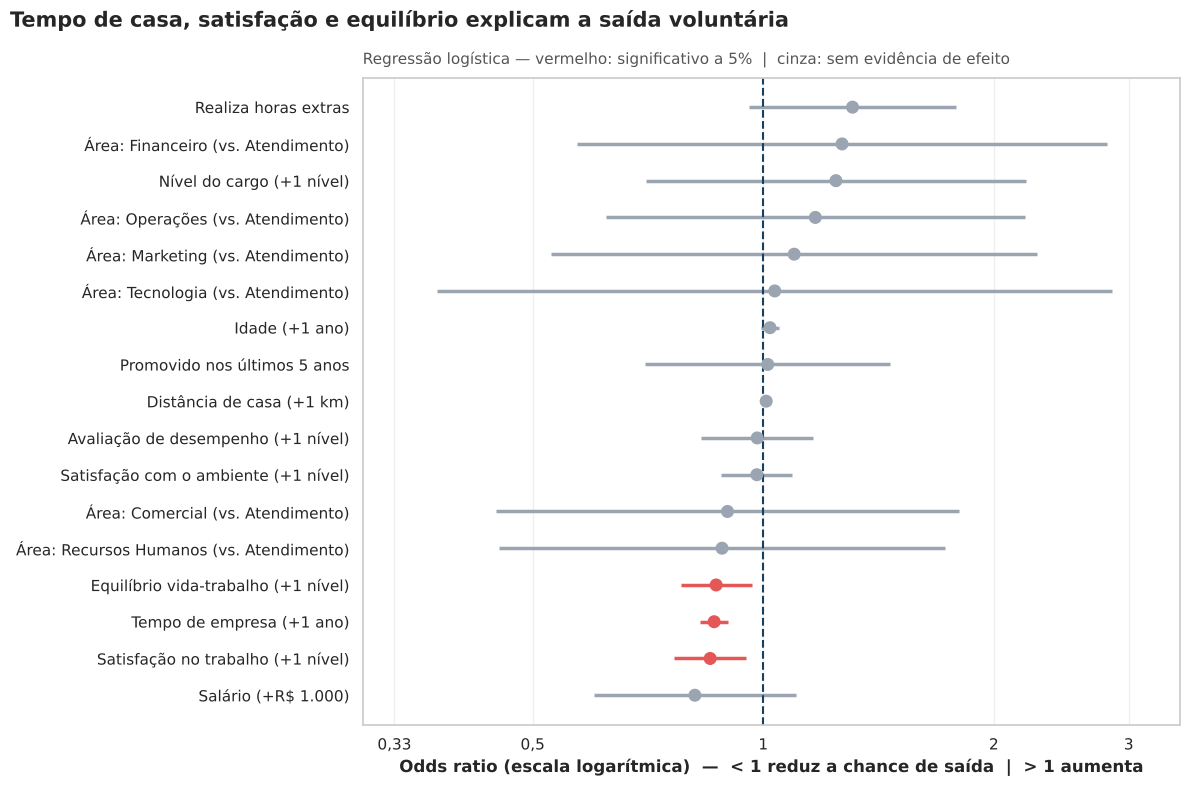

Gráfico salvo em: modelo_odds_ratio.png


In [6]:
# Gráfico de odds ratio com intervalo de confiança de 95%
grafico = resultados_modelo.sort_values("odds_ratio")
cores = np.where(grafico["significativo_5pct"].eq("Sim"), "#E45756", "#9AA5B1")

fig, ax = plt.subplots(figsize=(12, 8))

ax.hlines(
    y=grafico.index,
    xmin=grafico["ic_95_inferior"],
    xmax=grafico["ic_95_superior"],
    color=cores,
    linewidth=2.5,
)
ax.scatter(grafico["odds_ratio"], grafico.index, color=cores, s=70, zorder=3)
ax.axvline(1, color="#173F5F", linestyle="--", linewidth=1.5)

ax.set_xscale("log")
ax.set_xlim(0.3, 3.5)
ax.set_xticks([0.33, 0.5, 1, 2, 3])
ax.set_xticklabels(["0,33", "0,5", "1", "2", "3"])
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel(
    "Odds ratio (escala logarítmica)  —  < 1 reduz a chance de saída  |  > 1 aumenta",
    fontweight="bold",
)

fig.suptitle(
    "Tempo de casa, satisfação e equilíbrio explicam a saída voluntária",
    fontsize=15, fontweight="bold", x=0.01, ha="left",
)
ax.set_title(
    "Regressão logística — vermelho: significativo a 5%  |  cinza: sem evidência de efeito",
    fontsize=11, color="#555555", loc="left", pad=10,
)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

caminho_grafico = PASTA_IMAGENS / "modelo_odds_ratio.png"
fig.savefig(caminho_grafico, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {caminho_grafico.name}")

## 5. Validação do Modelo

Para verificar se o modelo generaliza para dados que não foram usados no ajuste, a base é dividida em **70% para treino** e **30% para teste**, mantendo a mesma proporção de saídas nas duas partes.

A métrica utilizada é a **AUC** (área sob a curva ROC):

- **0,5:** o modelo não é melhor que um sorteio;
- **0,7 a 0,8:** capacidade de discriminação aceitável;
- **acima de 0,8:** boa capacidade de discriminação.

In [7]:
# Divide a base em treino e teste de forma estratificada
treino, teste = train_test_split(
    base_modelo,
    test_size=0.3,
    random_state=SEMENTE,
    stratify=base_modelo["saida_voluntaria"],
)

# Ajusta o modelo apenas com a base de treino e calcula as probabilidades na base de teste
modelo_treino = smf.logit(formula, data=treino).fit(disp=False)
probabilidade_teste = modelo_treino.predict(teste)

auc_teste = roc_auc_score(teste["saida_voluntaria"], probabilidade_teste)
print(f"AUC na base de teste: {auc_teste:.3f}".replace(".", ","))

AUC na base de teste: 0,681


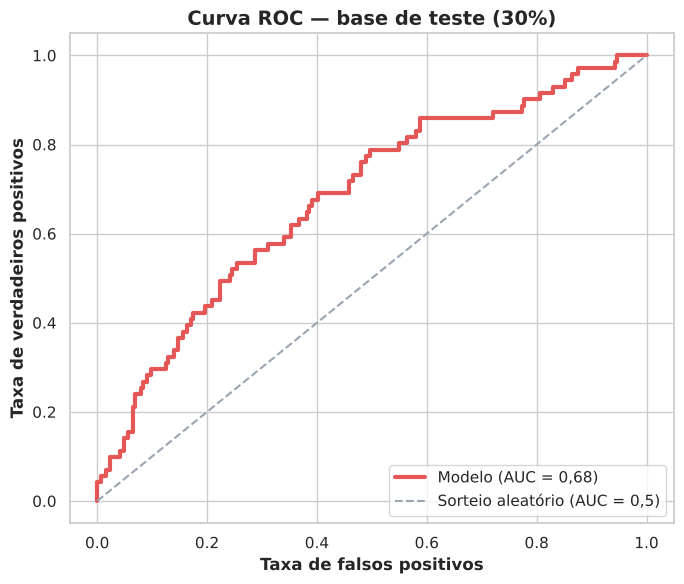

Gráfico salvo em: modelo_curva_roc.png


In [8]:
# Curva ROC na base de teste
falsos_positivos, verdadeiros_positivos, _ = roc_curve(
    teste["saida_voluntaria"], probabilidade_teste
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    falsos_positivos, verdadeiros_positivos, color="#E45756", linewidth=3,
    label=f"Modelo (AUC = {auc_teste:.2f})".replace(".", ","),
)
ax.plot([0, 1], [0, 1], color="#9AA5B1", linestyle="--", label="Sorteio aleatório (AUC = 0,5)")

ax.set_xlabel("Taxa de falsos positivos", fontweight="bold")
ax.set_ylabel("Taxa de verdadeiros positivos", fontweight="bold")
ax.set_title("Curva ROC — base de teste (30%)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()

caminho_grafico = PASTA_IMAGENS / "modelo_curva_roc.png"
fig.savefig(caminho_grafico, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico salvo em: {caminho_grafico.name}")

## 6. Conclusão Executiva — Modelo

Quando todos os fatores são avaliados em conjunto, **apenas três** continuam associados à saída voluntária:

| Fator | Odds ratio | Interpretação |
|---|---|---|
| Tempo de empresa | 0,86 | Cada ano a mais de casa reduz a chance de saída em cerca de **14%** |
| Satisfação no trabalho | 0,85 | Cada nível a mais na escala de 1 a 5 reduz a chance em cerca de **15%** |
| Equilíbrio vida-trabalho | 0,87 | Cada nível a mais na escala de 1 a 5 reduz a chance em cerca de **13%** |

**A promoção deixa de ter efeito** (odds ratio = 1,01; p-valor = 0,94). A associação observada na análise exploratória era explicada pelo tempo de empresa: quem tem mais tempo de casa teve mais oportunidades de ser promovido e também sai menos. Esse resultado mostra por que é importante não tirar conclusões a partir de comparações isoladas.

Área, salário, horas extras, nível do cargo, idade, distância e avaliação de desempenho **não apresentaram efeito significativo**. Horas extras (odds ratio = 1,31; p-valor = 0,09) ficaram próximas do limite e merecem acompanhamento com dados mais detalhados.

**Capacidade preditiva:** a AUC na base de teste foi de **0,68**. O modelo distingue quem sai de quem fica melhor do que o acaso, mas não é preciso o suficiente para prever saídas individuais. Seu uso adequado é **explicativo**: indicar quais alavancas de retenção têm maior respaldo nos dados.

### Limitações

- O tempo de empresa dos desligados é medido até a saída e o dos ativos até a data de referência. Uma **análise de sobrevivência** (por exemplo, curva de Kaplan-Meier ou modelo de Cox) trataria essa diferença de forma mais adequada;
- A base é sintética, e os resultados representam associações, não relações de causa e efeito;
- O modelo não deve ser utilizado para classificar ou tomar decisões sobre colaboradores individualmente.

## 7. Exportação dos Resultados

In [9]:
# Exporta os coeficientes do modelo para documentação e uso no dashboard
caminho_resultados = PASTA_DADOS_PROCESSADOS / "People_Analytics_Modelo_Odds_Ratio.csv"

resultados_modelo.rename_axis("variavel").reset_index().to_csv(
    caminho_resultados, index=False, encoding="utf-8-sig"
)

print(f"Resultados exportados: {caminho_resultados.name}")

Resultados exportados: People_Analytics_Modelo_Odds_Ratio.csv
